In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.morphology import skeletonize

from pyvane.graph.creation import graph_from_skeleton, remove_clusters
from pyvane.graph.refinement import refine_graph
from pyvane.util.misc import graph_to_img

skel = np.array(Image.open("test_image_corner.png").convert("L"))//255

init_graph = graph_from_skeleton(skel, keep_rings = True)
cond_graph = remove_clusters(init_graph, remove_degree_two=False, keep_rings=True)
simple_graph = refine_graph(
        cond_graph, 
        skel,
        multi_edge_threshold=0, 
        self_loop_threshold=0, 
        comp_size_threshold=0, 
        comp_length_threshold=0, 
        keep_rings=True,
        remove_degree_zero_nodes=False
        )
cond_graph = simple_graph

init_graph_img = graph_to_img(init_graph, img_shape=skel.shape, node_pixels_color=(1, 0, 0), edge_color=(2, 0, 0))[:,:,0]
cond_graph_img = graph_to_img(
    cond_graph, 
    img_shape=skel.shape, 
    node_color=(3, 0, 0),
    node_pixels_color=(1, 0, 0), 
    edge_color=(2, 0, 0)
    )[:,:,0]

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs = axs.flatten()

viz_img1 = np.zeros((*skel.shape, 3), dtype=np.uint8)
viz_img1[(skel == 1) & (init_graph_img > 0)] = (0, 255, 0)
viz_img1[(skel == 1) & (init_graph_img == 0)] = (255, 0, 0)
viz_img1[(skel == 0) & (init_graph_img > 0)] = (0, 0, 255)

viz_img2 = np.zeros((*skel.shape, 3), dtype=np.uint8)
viz_img2[cond_graph_img == 1] = (180, 0, 0)
viz_img2[cond_graph_img == 2] = (0, 0, 255)
viz_img2[cond_graph_img == 3] = (255, 0, 0)


axs[0].imshow(viz_img1)
axs[1].imshow(viz_img2)

ImportError: cannot import name 'graph_from_skeleton' from 'pyvane.graph.creation_v2' (/home/chcomin/Dropbox/ufscar/pyvane/pyvane/graph/creation_v2.py)

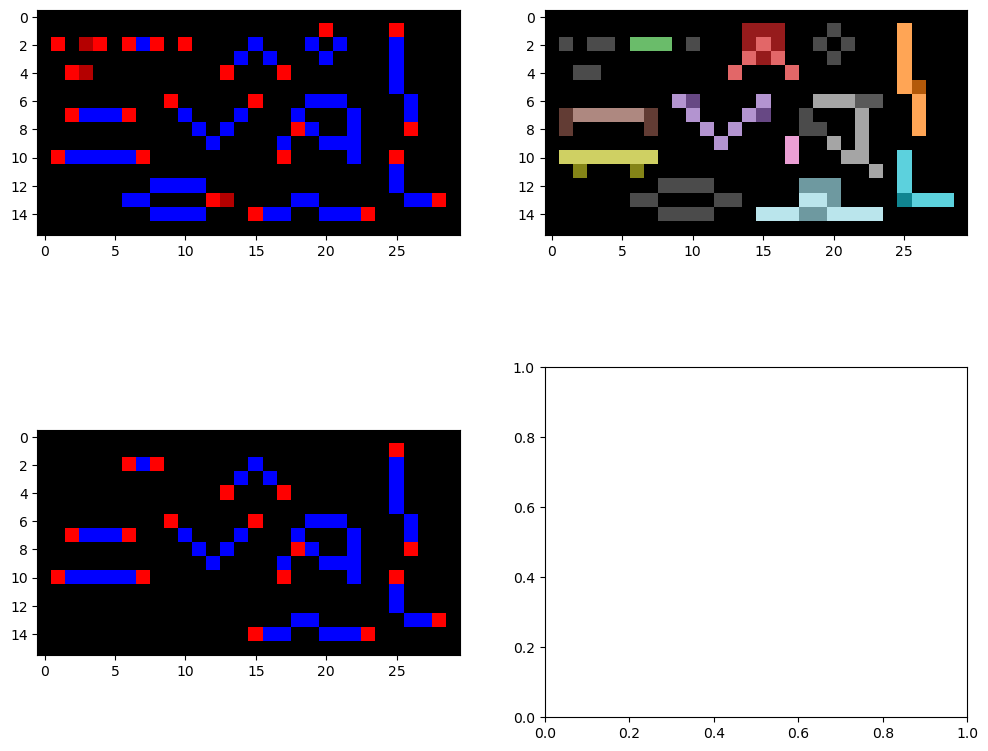

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.morphology import skeletonize

from pyvane.graph.creation import (
    graph_from_skeleton,
    map_foreground_to_graph,
    remove_clusters,
)
from pyvane.graph.refinement import refine_graph
from pyvane.util.misc import graph_to_img

img = np.array(Image.open("test_image_corner.png").convert("L"))//255
skel = skeletonize(img).astype(np.uint8)

keep_rings = True

init_graph = graph_from_skeleton(skel, keep_rings = keep_rings)
cond_graph = remove_clusters(init_graph, remove_degree_two=True, keep_rings=keep_rings)
simple_graph, edt_bg, trash_paths = refine_graph(
        cond_graph, 
        img,
        bulge_len_threshold = 5.0,
        bulge_size_threshold = 0.0,
        bulge_ratio_threshold = 0.0,
        elongation_threshold = 0.,
        multi_edge_threshold = 0., 
        self_loop_threshold = 0., 
        bridge_radius_ratio_threshold = 0.5,
        bridge_length_threshold = 3.,
        collapse_length_ratio_threshold = 1.,
        comp_size_threshold = 0, 
        comp_length_threshold = 1, 
        keep_rings = False
        )

labeled_volume, mappings = map_foreground_to_graph(
    simple_graph, img, edt_bg, trash_paths=trash_paths)
labeled_volume[labeled_volume==999999] = 0
for id in mappings["id_node_map"]:
    labeled_volume[labeled_volume==id] = 0

cond_graph_img = graph_to_img(
    cond_graph, 
    img_shape=skel.shape, 
    node_color=(3, 0, 0),
    node_pixels_color=(1, 0, 0), 
    edge_color=(2, 0, 0)
    )[:,:,0]

simple_graph_img = graph_to_img(
    simple_graph, 
    img_shape=skel.shape, 
    node_color=(3, 0, 0),
    node_pixels_color=(0, 0, 0), 
    edge_color=(2, 0, 0)
    )[:,:,0]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

viz_img2 = np.zeros((*skel.shape, 3), dtype=np.uint8)
viz_img2[cond_graph_img == 1] = (180, 0, 0)
viz_img2[cond_graph_img == 2] = (0, 0, 255)
viz_img2[cond_graph_img == 3] = (255, 0, 0)

viz_img3 = np.zeros((*skel.shape, 3), dtype=np.uint8)
viz_img3[simple_graph_img == 1] = (180, 0, 0)
viz_img3[simple_graph_img == 2] = (0, 0, 255)
viz_img3[simple_graph_img == 3] = (255, 0, 0)

cmap = plt.get_cmap("tab20").copy()
cmap.set_under("black")

axs[0].imshow(viz_img2)
axs[1].imshow(labeled_volume, cmap=cmap, vmin=1)
axs[1].imshow(skel, "gray", alpha=0.3)
axs[2].imshow(viz_img3)


In [24]:
init_graph = graph_from_skeleton(skel, keep_rings = True)
cond_graph = remove_clusters(init_graph, remove_degree_two=True, keep_rings=True)
simple_graph, _ = refine_graph(
        cond_graph, 
        img,
        bulge_len_threshold = 4.0,
        bulge_size_threshold = 0.0,
        bulge_ratio_threshold = 0.0,
        elongation_threshold = 0.,
        multi_edge_threshold = None, 
        self_loop_threshold = None, 
        bridge_radius_ratio_threshold = 0.5,
        bridge_length_threshold = 3.,
        collapse_length_ratio_threshold = 1.,
        comp_size_threshold = 0, 
        comp_length_threshold = 1, 
        keep_rings = False
        )

In [25]:
from pyvane.graph.adjustment import adjust_graph, simplify
from pyvane.graph.creation import create_graph
from pyvane.util.image import Image

pv_img = Image(skel)

g = create_graph(pv_img)
g = simplify(g, False)
graph_final = adjust_graph(g, length_threshold=0)

In [33]:
from scipy.ndimage import generate_binary_structure

generate_binary_structure(2, 3)

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [63]:
import networkx as nx


def check_graph_artifacts(graph, return_ids=True):
    stats = {
        "is_multigraph_class": graph.is_multigraph(),
        "self_loop_count": nx.number_of_selfloops(graph),
        "multi_edge_count": graph.number_of_edges() - len(set(graph.edges())),
        "zero_degree_count": sum(1 for node in graph.nodes() if graph.degree(node) == 0)
    }

    if not return_ids:
        return stats
    
    self_loop_ids = list(nx.selfloop_edges(graph, keys=True))
    
    # 1. Identify pairs (u, v) that have more than one edge
    parallel_pairs = [(u, v) for u, v in graph.edges(keys=False) if graph.number_of_edges(u, v) > 1]

    # 2. Get the unique set of these pairs (to avoid duplicates from the edge list)
    unique_parallel_pairs = {tuple(sorted(pair)) for pair in parallel_pairs}

    # 3. Get the full (u, v, key) IDs for every parallel edge
    parallel_edge_ids = []
    for u, v in unique_parallel_pairs:
        for key in graph[u][v]:
            parallel_edge_ids.append((u, v, key))

    stats = {**stats, "parallel_edge_ids": parallel_edge_ids, "self_loop_ids": self_loop_ids}

    return stats

check_graph_artifacts(simple_graph, return_ids=True)

{'is_multigraph_class': True,
 'self_loop_count': 0,
 'multi_edge_count': 0,
 'zero_degree_count': 0,
 'parallel_edge_ids': [],
 'self_loop_ids': []}